In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
np.random.seed(42)

In [151]:
wine = load_wine()
X = wine.data
y = wine.target  # true labels, only used later for evaluation/comparison

df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

print("Shape of data:", X.shape)
print("Classes:", np.unique(y), "-> counts:", np.bincount(y))
df.head()

Shape of data: (178, 13)
Classes: [0 1 2] -> counts: [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [152]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [153]:
print("mising data is", df.isnull().sum().sum())
df.shape

mising data is 0


(178, 14)

beforepca


In [154]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(178, 13)


Text(0, 0.5, 'Inertia')

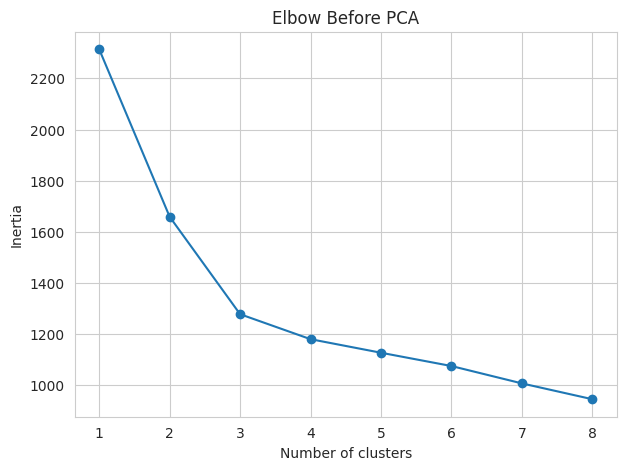

In [155]:
inertia = []
for k in range(1,9):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,9), inertia , marker='o')
plt.title('Elbow Before PCA')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

Shape of data after PCA: (178, 13)


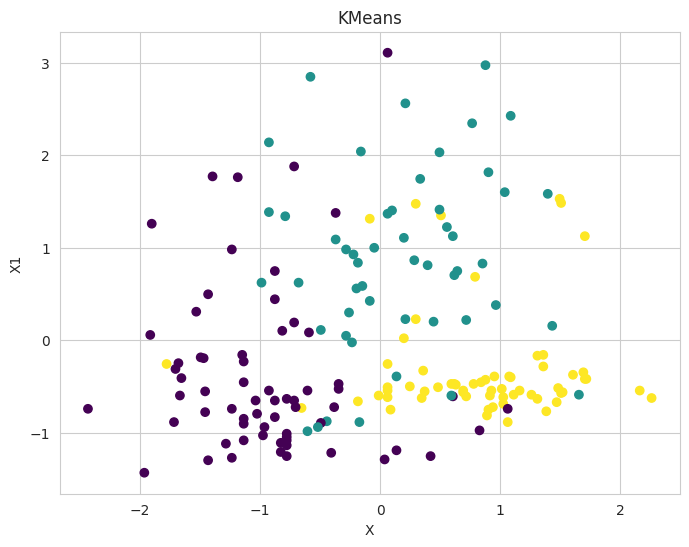

Silhouette Score: 0.2848589191898987


In [156]:
kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
clusters=kmeans.fit_predict(X_scaled)

print("Shape of data after PCA:", X_scaled.shape)

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters,  cmap="viridis")
plt.title("KMeans")
plt.xlabel("X")
plt.ylabel("X1")
plt.show()
silhouette_avg = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", silhouette_avg)

pca


Shape of data after PCA: (178, 2)


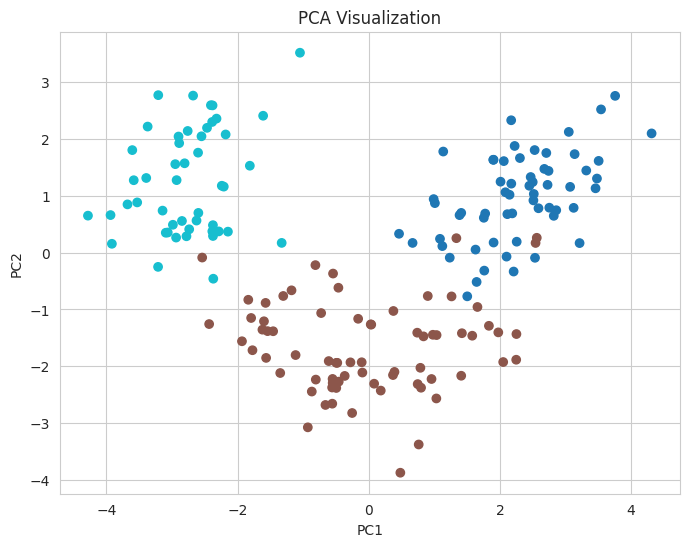

In [157]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape of data after PCA:", X_pca.shape)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10")
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [158]:
kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
clusters1=kmeans.fit_predict(X_pca)

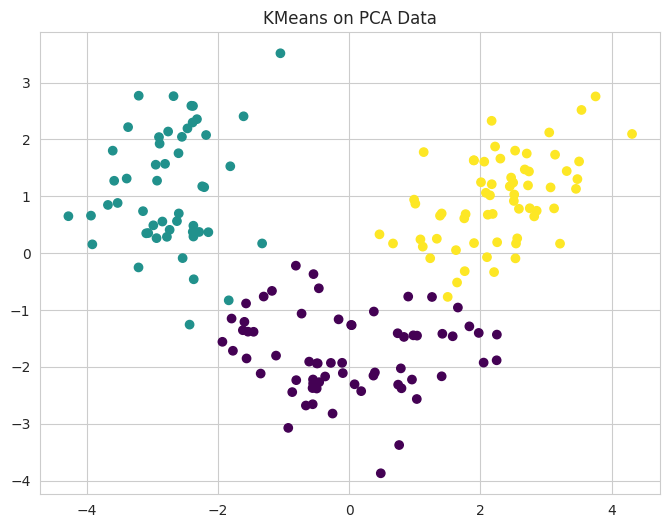

Silhouette Score: 0.5610505693103246


In [159]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("KMeans on PCA Data")
plt.show()
silhouette_avg = silhouette_score(X_pca, clusters1)
print("Silhouette Score:", silhouette_avg)

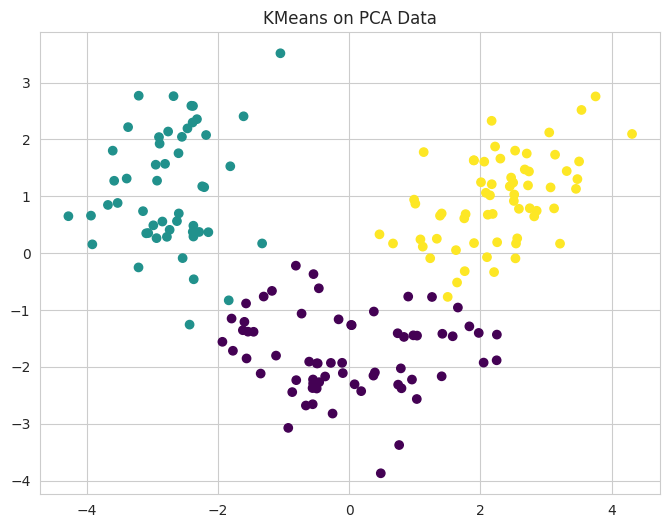

Silhouette Score: 0.5610505693103246


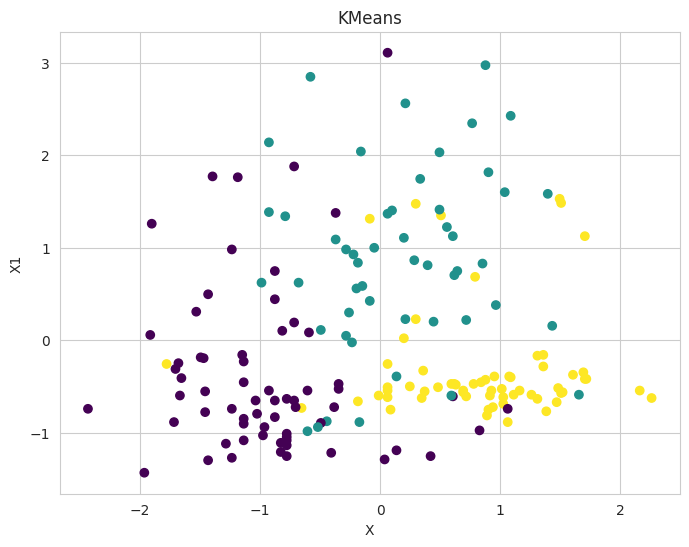

Silhouette Score: 0.2848589191898987


In [160]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("KMeans on PCA Data")
plt.show()
silhouette_avg = silhouette_score(X_pca, clusters1)
print("Silhouette Score:", silhouette_avg)


plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters,  cmap="viridis")
plt.title("KMeans")
plt.xlabel("X")
plt.ylabel("X1")
plt.show()
silhouette_avg = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", silhouette_avg)

dpscan before



In [161]:
db = DBSCAN(eps=1.6, min_samples=6)
df['Cluter_DB3'] = db.fit_predict(X_scaled)
s1 = silhouette_score( X_scaled ,  df['Cluter_DB3'])
print('Silhouette Score: ', s1)


Silhouette Score:  -0.016182011264898974


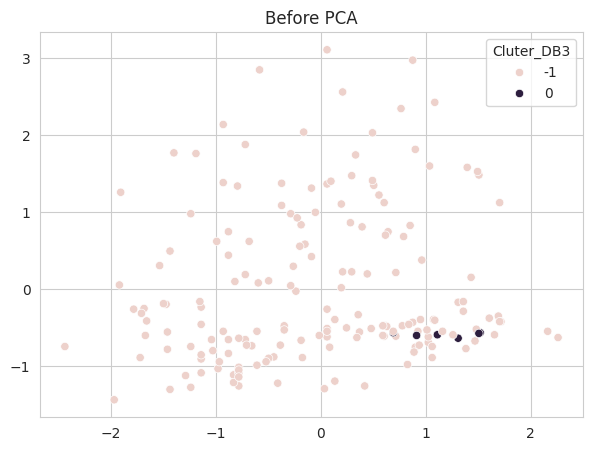

In [162]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['Cluter_DB3'])
plt.title('Before PCA')
plt.show()


after


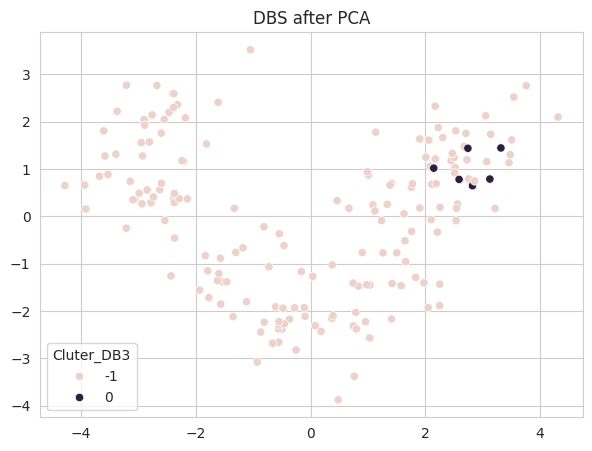


After PCA - Clusters: 9, Noise points: 60
After PCA - Silhouette Score: 0.4975094473351549


In [163]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

db_after = DBSCAN(eps=0.4, min_samples=5)
labels_after = db_after.fit_predict(X_pca)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluter_DB3'])
plt.title('DBS after PCA')
plt.show()


n_clusters_after = len(set(labels_after)) - (1 if -1 in labels_after else 0)
print(f"\nAfter PCA - Clusters: {n_clusters_after}, Noise points: {list(labels_after).count(-1)}")

if n_clusters_after > 1:
    score_after = silhouette_score(X_pca[labels_after != -1], labels_after[labels_after != -1])
    print("After PCA - Silhouette Score:", score_after)

analiss

In [164]:
print(X_scaled.shape)
print(X_pca.shape)


(178, 13)
(178, 2)


1. How did PCA affect the clustering results?

PCA improved the clustering results. Before applying PCA, K-Means on the original 13 standardized features achieved a Silhouette Score of 0.285. After reducing the data to 2 principal components, the Silhouette Score increased to 0.561. This indicates that the clusters became more compact and better separated after PCA.

2. Did the visualization become clearer?

Yes.
After PCA, the data was reduced from 13 dimensions to 2 dimensions, making it possible to visualize the clusters on a 2D plot (PC1 vs. PC2). The cluster boundaries appeared more distinct and were easier to interpret compared to the original feature space.

3. Did you lose important information?

Yes.
The first two principal components retained only 55.41% of the total variance, meaning approximately 44.59% of the original information was discarded. This indicates that while PCA simplified the data, it also removed a considerable amount of information that could influence clustering performance.

In [165]:

explained_var = pca.explained_variance_ratio_
print("Explained variance ratio per component:", np.round(explained_var, 4))
print(f"Total variance retained by 2 components: {explained_var.sum()*100:.2f}%")


Explained variance ratio per component: [0.362  0.1921]
Total variance retained by 2 components: 55.41%


4. Which approach is better and why?

For this dataset, K-Means after PCA performed better. It produced a higher Silhouette Score (0.561) than K-Means on the original data (0.285), indicating better cluster quality. PCA also simplified the data and made the clusters much easier to visualize and interpret.

Applying PCA before K-Means improved both the clustering quality and the visualization. The higher Silhouette Score and the clearer separation of clusters show that PCA was the better approach for your Wine dataset.

**Insights**

PCA reduced the data from 13 features to 2 components, making it easier to understand and visualize.
The first two components kept 55.41% of the original information.
The clusters became easier to see on the graph after applying PCA.
However, about 44.59% of the information was lost, so some details from the original data were removed.
Overall, PCA is useful for visualization, while the original data is better when you want to keep all the information for clustering.